# Week 2 — Exploratory Data Analysis

Week 1 established *what* the data is: 2,200 rows, seven numeric features, one
`label` column holding 22 crop names, validated on every load. It deliberately
stopped there.

This notebook asks the next question: **what do those numbers actually look
like?** Concretely —

1. How are the features distributed, and how spread out are they?
2. Is the dataset balanced across the 22 crops?
3. Which features vary strongly *between* crops, and which do not?
4. Are any features telling us the same thing as each other?
5. Are there anomalous values, and if so, what are they?

Nothing here is preprocessed and nothing is modelled. No column is dropped, no
row is deleted, no value is rescaled — the raw file is read and left exactly as
it was found. Preparation is **Week 3**; modelling is **Week 4**.

The narrative explanation of every technique used below lives in
[`docs/curriculum/week02/learning_notes.md`](../docs/curriculum/week02/learning_notes.md).

## 0. Setup

The first cell puts the repository root on `sys.path` so `src` is importable
from inside `notebooks/` — the same trick as Week 1, explained in that week's
learning notes §8.

The plotting code itself lives in `src/utils/eda.py`, not in this notebook.
That is a deliberate rule of this project: logic lives in `src/` where it can be
linted and tested (`tests/test_eda.py`), and notebooks are the *narrative* that
calls it. A plot defined inline in a cell can only ever be checked by a human
looking at it.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data import EXPECTED_LABEL_COUNT, FEATURE_COLUMNS, TARGET_COLUMN, load_data
from src.utils.eda import (
    class_balance,
    count_outliers_iqr,
    describe_features,
    plot_boxplot_by_label,
    plot_class_balance,
    plot_correlation_heatmap,
    plot_feature_histograms,
    separation_scores,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

print("pandas", pd.__version__, "| seaborn", sns.__version__)

pandas 2.2.3 | seaborn 0.13.2


In [2]:
crops = load_data()          # reads the CSV and validates it in one step (Week 1)
FEATURES = list(FEATURE_COLUMNS)
crops.shape

(2200, 8)

`(2200, 8)` — unchanged from Week 1, as it must be: `validate_dataset()` would
have raised before this line if the file had drifted.

## 1. Descriptive statistics

A **descriptive statistic** compresses a whole column into one number. Three
families matter here:

* **centre** — `mean` (the average, pulled around by extreme values) and
  `median` (the middle value, which is not).
* **spread** — `std`, the standard deviation: roughly the typical distance of a
  value from the mean, in the feature's own units.
* **shape** — the quartiles `25%`/`50%`/`75%`, the `min`/`max`, and `skew`,
  which is positive when a column has a long right tail.

`describe_features()` is `DataFrame.describe()` transposed (one row per
feature, which reads better when there are seven) with `median` and `skew`
added.

In [3]:
summary = describe_features(crops, FEATURES)
summary.round(2)

,count,mean,std,min,25%,50%,75%,max,median,skew
N,2200.0,50.55,36.92,0.00,21.00,37.00,84.25,140.00,37.00,0.51
P,2200.0,53.36,32.99,5.00,28.00,51.00,68.00,145.00,51.00,1.01
K,2200.0,48.15,50.65,5.00,20.00,32.00,49.00,205.00,32.00,2.38
temperature,2200.0,25.62,5.06,8.83,22.77,25.60,28.56,43.68,25.60,0.18
humidity,2200.0,71.48,22.26,14.26,60.26,80.47,89.95,99.98,80.47,-1.09
ph,2200.0,6.47,0.77,3.50,5.97,6.43,6.92,9.94,6.43,0.28
rainfall,2200.0,103.46,54.96,20.21,64.55,94.87,124.27,298.56,94.87,0.97


Read row by row, this table is already informative:

* The seven features live on **wildly different scales**: `ph` spans roughly
  3.5–9.9 while `K` spans 5–205. Distance-based algorithms treat a difference of
  1 in `ph` as exactly as important as a difference of 1 in `K`, so this table is
  the evidence that Week 3 will need to scale features.
* `mean` and `median` diverge sharply for `K` (48.15 vs 32.00), matching its
  large positive `skew` of 2.38.
* `humidity` has a *negative* skew (-1.09): most rows sit high, with a tail
  reaching down to 14%.
* No `count` is below 2,200, confirming again that nothing is missing.

## 2. Class balance

**Class balance** is how many rows each class has. It matters for two reasons
that arrive later:

* **Model behaviour** — a classifier trained where 95% of rows are one class can
  score 95% accuracy by always predicting that class, having learned nothing.
* **Metric choice** — accuracy is only a fair summary when classes are balanced.
  Week 8 revisits this with precision, recall and the confusion matrix.

In [4]:
balance = class_balance(crops, TARGET_COLUMN)
balance

,count,proportion
label,,
rice,100,0.045455
maize,100,0.045455
chickpea,100,0.045455
kidneybeans,100,0.045455
pigeonpeas,100,0.045455
mothbeans,100,0.045455
mungbean,100,0.045455
blackgram,100,0.045455
lentil,100,0.045455


In [5]:
print("classes:", crops[TARGET_COLUMN].nunique(), "(expected", EXPECTED_LABEL_COUNT, ")")
print("min rows per class:", int(balance["count"].min()))
print("max rows per class:", int(balance["count"].max()))

classes: 22 (expected 22 )
min rows per class: 100
max rows per class: 100


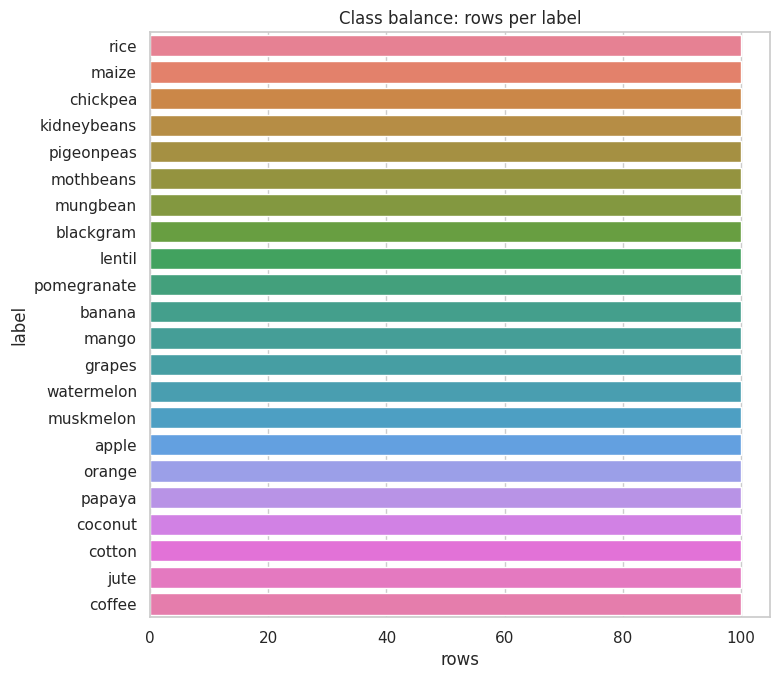

In [6]:
plot_class_balance(crops, TARGET_COLUMN)
plt.show()

Exactly 100 rows for each of the 22 crops, 4.55% apiece — a **perfectly
balanced** dataset, and the bar chart is a row of identical bars.

This is convenient and *unrealistic*. Real agricultural records would be
dominated by whatever is commonly grown in the region that collected them. Two
consequences to carry forward:

1. Accuracy is a defensible headline metric **on this dataset**, which is why
   Week 4 can use it for a baseline without apology.
2. Any claim of the form "this model handles rare crops well" is unsupported
   here, because this dataset contains no rare crops. The balance is a property
   of the file, not of the world.

## 3. Distributions — one histogram per feature

A **histogram** slices a feature's range into bins and counts how many rows fall
into each. It shows things a mean cannot: whether values pile up at one end,
whether there is a hard floor or ceiling, and whether there are *two* peaks —
which usually means two different populations have been mixed together.

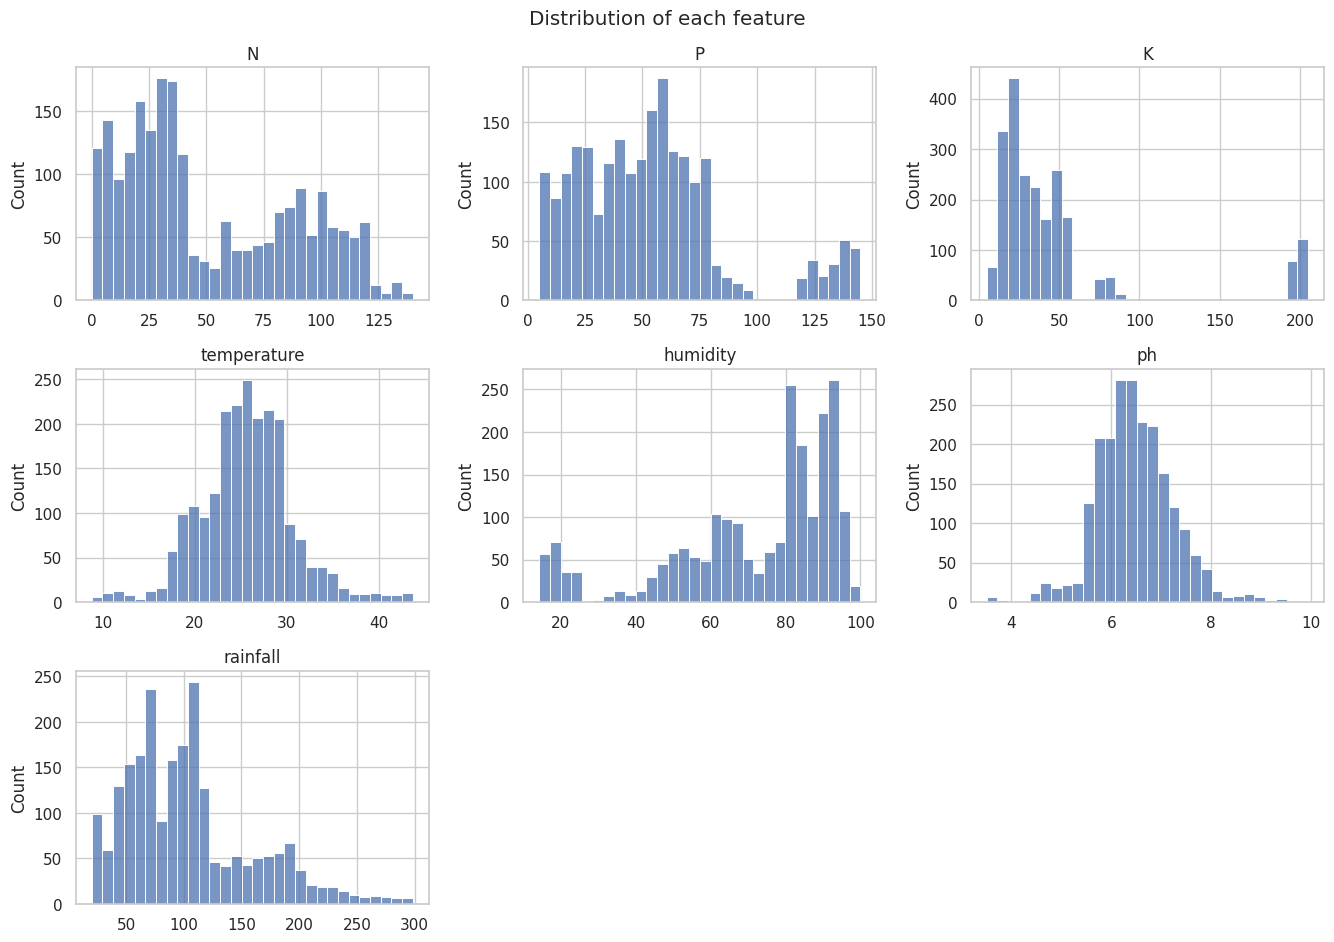

In [7]:
plot_feature_histograms(crops, FEATURES, bins=30)
plt.show()

Three shapes are worth naming:

* **`K` and `P` are strongly right-skewed**, each with a detached cluster far to
  the right. That is not noise — §4 and §5 identify it as apple and grapes,
  whose potassium requirement is roughly four times every other crop's.
* **`humidity` is left-skewed**: a dense mass above 80% with a thin tail
  reaching down toward 15%.
* **`temperature` and `ph` are close to symmetric and single-peaked**, centred
  near 25 °C and pH 6.5 — plausible agronomic values.

The key interpretive point: these are histograms of *all 22 crops pooled
together*. A multi-peaked pooled histogram in a labelled dataset is expected —
each crop contributes its own hump. The interesting question is not "is the
overall column skewed" but "do the per-crop humps sit in different places",
which is what §5 and §6 answer.

## 4. Correlation between features

**Correlation** measures how strongly two features move together, on a scale
from -1 to +1. The Pearson coefficient used here captures *linear* association
only: a correlation of 0 means no straight-line relationship, not "no
relationship".

Why it matters later:

* Two near-identical features add computation and confuse any per-feature
  importance story (Week 7) without adding information.
* Linear models become unstable when their inputs are strongly correlated
  (multicollinearity): the fitted coefficients can swing wildly.
* Tree-based models are largely untroubled by it, which is one reason they are a
  strong default on tabular data (Week 5).

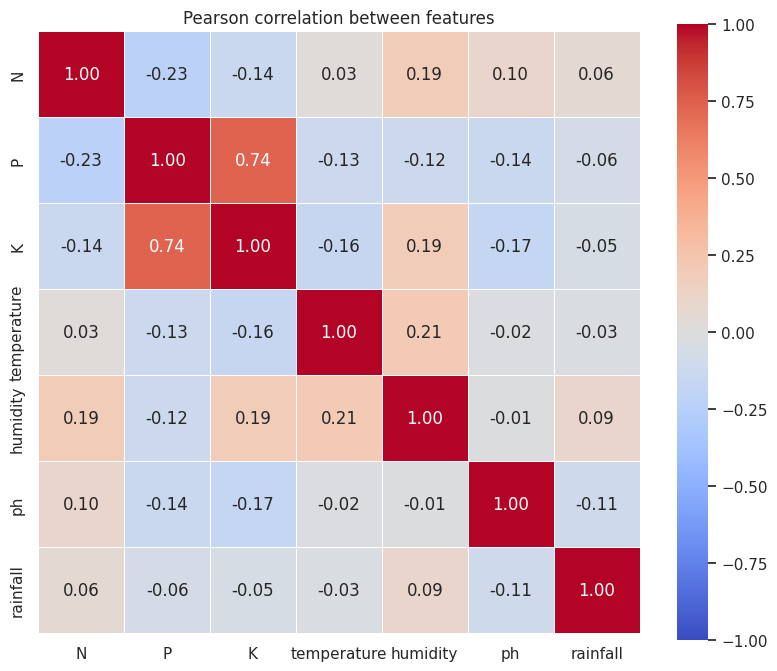

In [8]:
plot_correlation_heatmap(crops, FEATURES)
plt.show()

In [9]:
crops[FEATURES].corr().round(2)

,N,P,K,temperature,humidity,ph,rainfall
N,1.00,-0.23,-0.14,0.03,0.19,0.10,0.06
P,-0.23,1.00,0.74,-0.13,-0.12,-0.14,-0.06
K,-0.14,0.74,1.00,-0.16,0.19,-0.17,-0.05
temperature,0.03,-0.13,-0.16,1.00,0.21,-0.02,-0.03
humidity,0.19,-0.12,0.19,0.21,1.00,-0.01,0.09
ph,0.10,-0.14,-0.17,-0.02,-0.01,1.00,-0.11
rainfall,0.06,-0.06,-0.05,-0.03,0.09,-0.11,1.00


Only one pair stands out: **`P` and `K` correlate at +0.74**. Everything else
sits between -0.23 and +0.21, i.e. essentially unrelated in linear terms.

It is worth asking *why* that pair correlates rather than just recording that it
does:

In [10]:
without_high_k = crops[~crops[TARGET_COLUMN].isin(["apple", "grapes"])]
pk_all = round(crops["P"].corr(crops["K"]), 3)
pk_rest = round(without_high_k["P"].corr(without_high_k["K"]), 3)
print("P-K correlation, all 22 crops      :", pk_all)
print("P-K correlation, minus apple/grapes:", pk_rest)

P-K correlation, all 22 crops      : 0.736
P-K correlation, minus apple/grapes: 0.043


The correlation is almost entirely produced by two of the 22 crops. Apple and
grapes need both high phosphorus and high potassium; remove those 200 rows and
the association collapses from 0.74 to 0.04.

This is a general lesson about correlation on a labelled dataset: a
population-level coefficient can be an artifact of class structure rather than a
property of the features themselves. So `P` and `K` are **not** redundant — they
are jointly informative precisely because their combination identifies a
specific pair of crops. Neither will be dropped.

## 5. Outliers — boxplots per feature, grouped by crop

A **boxplot** draws the interquartile range as a box (25th to 75th percentile)
with the median inside it, whiskers extending 1.5 IQR beyond the box, and every
point past the whiskers plotted individually. Those individual points are what
people call **outliers**.

Two things must be said plainly:

* "Outlier" is the output of an arithmetic rule, **not** a verdict of "wrong".
* We are looking, and removing nothing. Deleting rows because they are unusual
  destroys exactly the extremes a recommender needs in order to tell a demanding
  crop apart from an average one.

First, count what the rule flags on the pooled data:

In [11]:
count_outliers_iqr(crops, FEATURES).round(2)

,lower_bound,upper_bound,n_outliers,pct_outliers
feature,,,,
N,-73.88,179.12,0,0.00
P,-32.00,128.00,138,6.27
K,-23.50,92.50,200,9.09
temperature,14.08,37.25,86,3.91
humidity,15.73,134.48,30,1.36
ph,4.54,8.35,57,2.59
rainfall,-25.02,213.84,100,4.55


Now the same features split by crop. The grouping is the whole point: a value
that is extreme for the dataset as a whole is often perfectly ordinary for its
own crop.

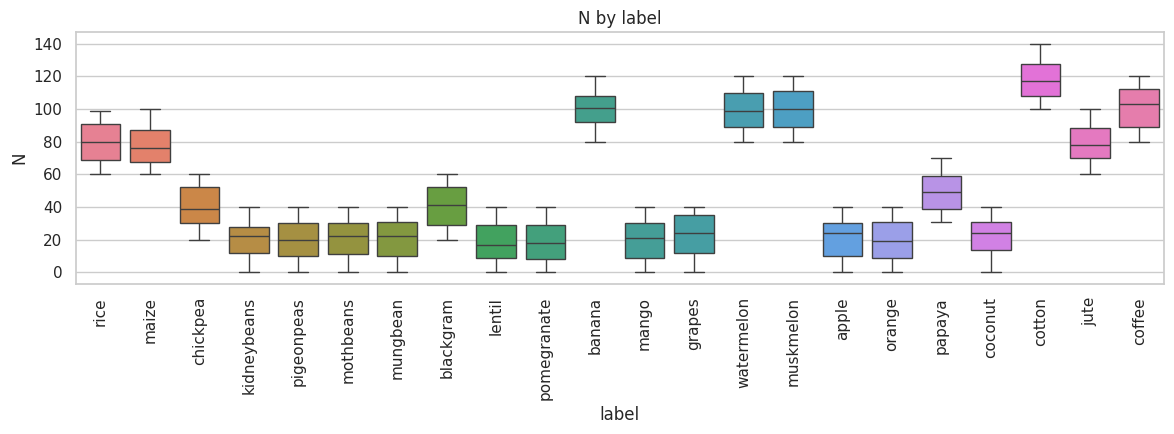

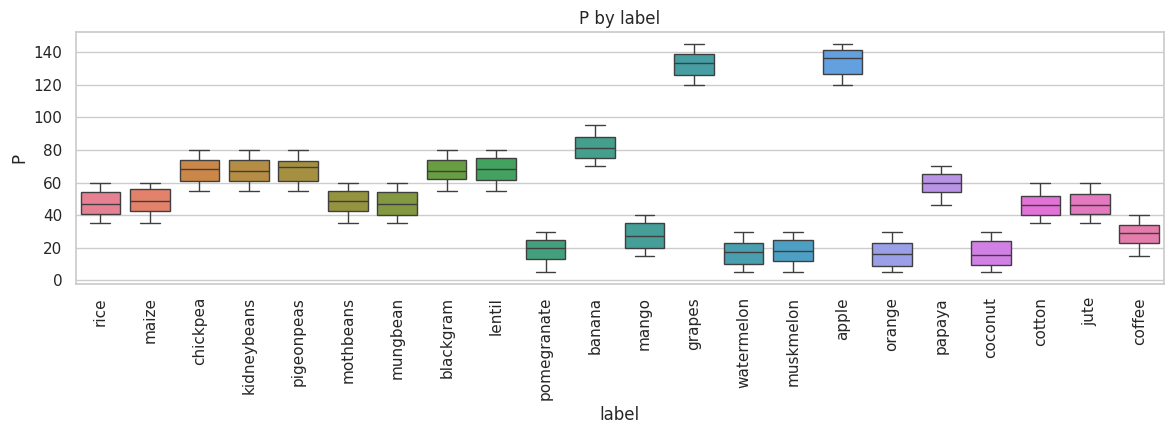

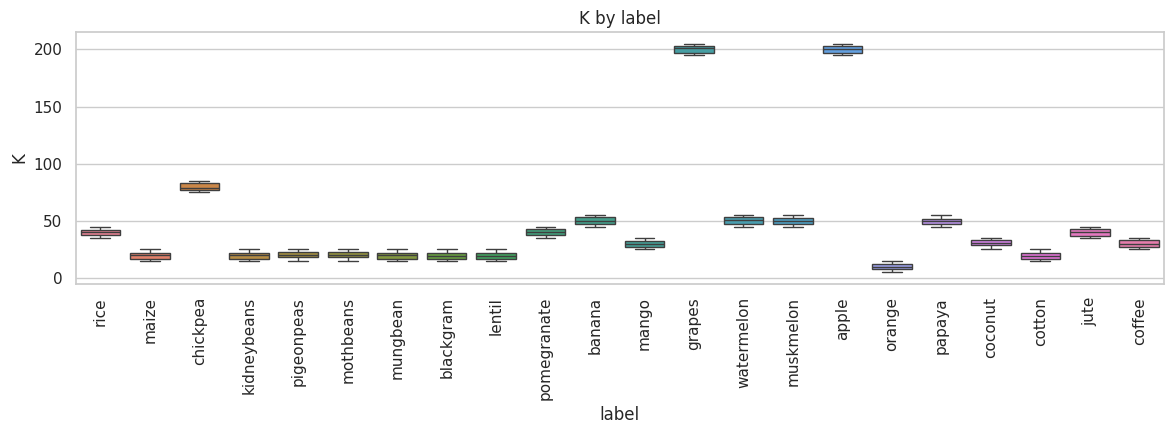

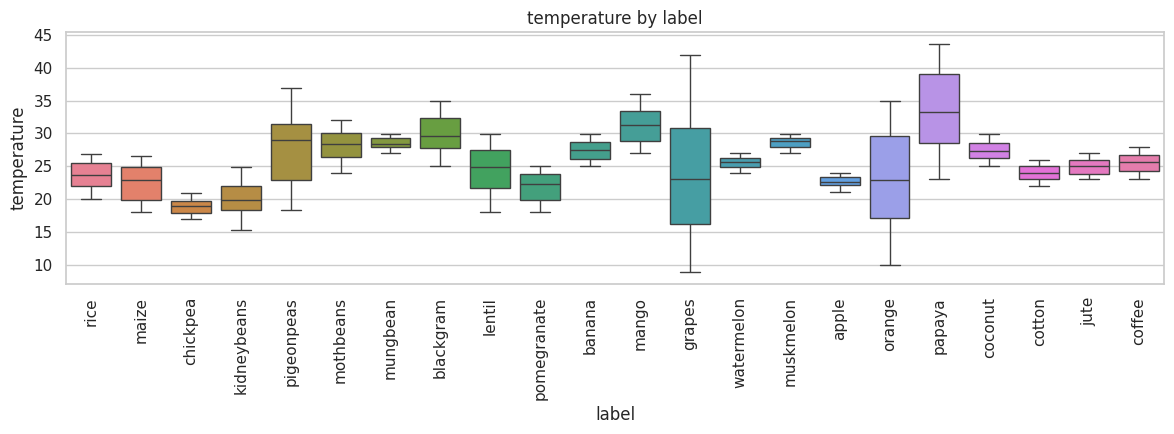

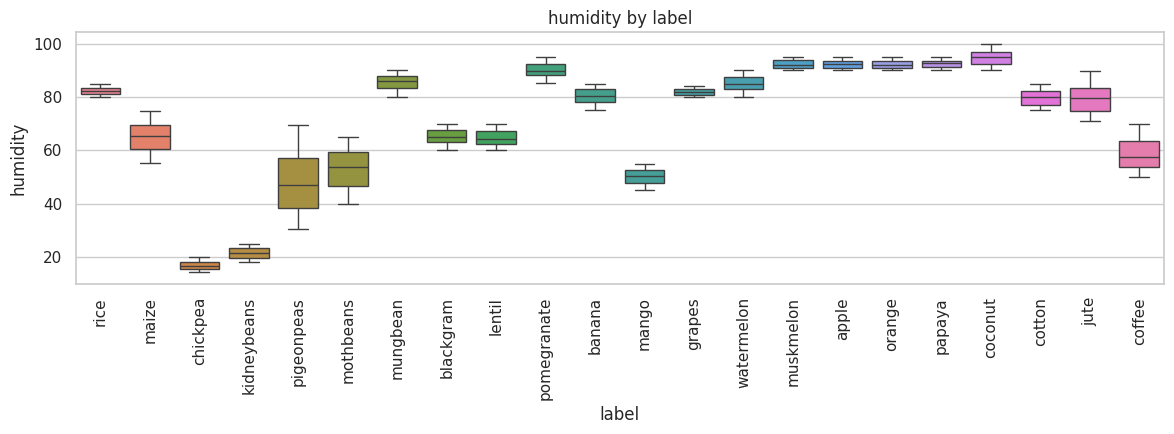

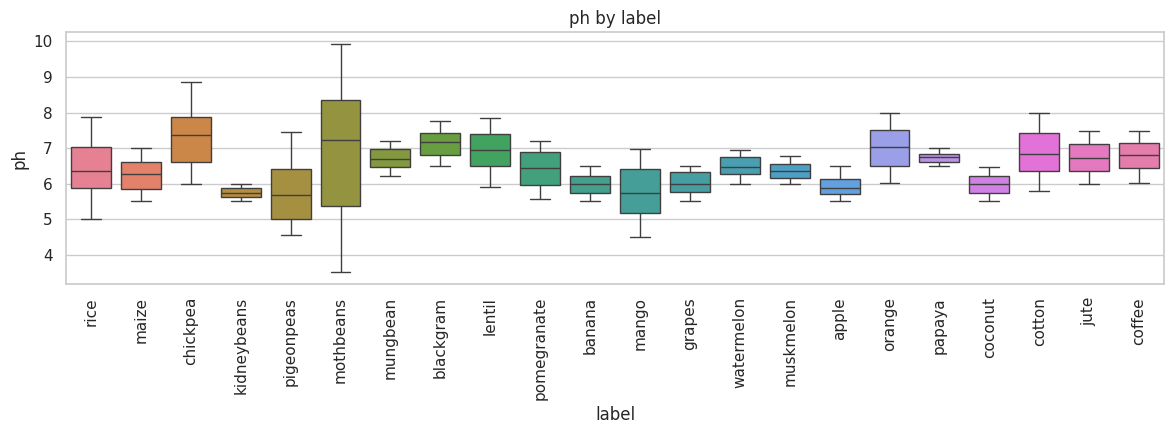

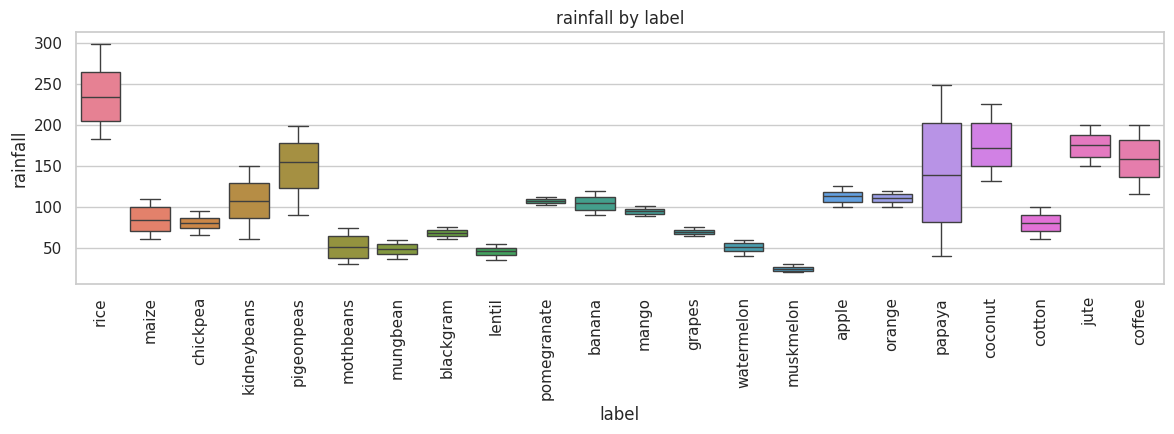

In [12]:
for feature in FEATURES:
    plot_boxplot_by_label(crops, feature, TARGET_COLUMN)
    plt.tight_layout()
    plt.show()

Checking whether the flagged values are anomalies or just class structure:

In [13]:
for name, mask in [
    ("K above upper whisker (92.5)", crops["K"] > 92.5),
    ("humidity below lower whisker (15.73)", crops["humidity"] < 15.73),
    ("rainfall above upper whisker (213.84)", crops["rainfall"] > 213.84),
]:
    print(name, "->", crops.loc[mask, TARGET_COLUMN].value_counts().to_dict())

K above upper whisker (92.5) -> {'grapes': 100, 'apple': 100}
humidity below lower whisker (15.73) -> {'chickpea': 30}
rainfall above upper whisker (213.84) -> {'rice': 68, 'papaya': 17, 'coconut': 15}


Every flagged group resolves to a crop, not to a data error:

* All 200 high-`K` rows are apple and grapes — 100 of each, their *entire*
  populations.
* All 30 very-dry rows are chickpea, whose humidity range is 14.3–20.0%.
* The high-rainfall rows are rice, papaya and coconut.

So the IQR rule is flagging **legitimate sub-populations**, not corrupt
measurements. Removing them would delete two crops' worth of signal and make
apple and grapes unlearnable. Week 2 removes nothing; any preprocessing decision
waits for Week 3, where it can be made on training data alone.

## 6. Which features separate the crops?

The boxplots suggest visually that some features separate crops far better than
others. `separation_scores()` puts a number on that impression: for each feature
it reports **eta-squared**, the share of that feature's total variance that lies
*between* crops rather than within them. 0 means every crop looks the same on
this feature; 1 means the crops are perfectly separated by it alone.

This is a description of what the plots show, not a feature-selection decision.
A feature can be weak alone and valuable in combination, so nothing is dropped
on the strength of this table.

In [14]:
separation_scores(crops, FEATURES, TARGET_COLUMN).round(3)

K              0.996
humidity       0.968
P              0.948
N              0.896
rainfall       0.854
temperature    0.496
ph             0.368
Name: eta_squared, dtype: float64

In [15]:
crops.groupby(TARGET_COLUMN)[FEATURES].mean().round(1).sort_values("rainfall")

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
muskmelon,100.3,17.7,50.1,28.7,92.3,6.4,24.7
lentil,18.8,68.4,19.4,24.5,64.8,6.9,45.7
mungbean,21.0,47.3,19.9,28.5,85.5,6.7,48.4
watermelon,99.4,17.0,50.2,25.6,85.2,6.5,50.8
mothbeans,21.4,48.0,20.2,28.2,53.2,6.8,51.2
blackgram,40.0,67.5,19.2,30.0,65.1,7.1,67.9
grapes,23.2,132.5,200.1,23.8,81.9,6.0,69.6
chickpea,40.1,67.8,79.9,18.9,16.9,7.3,80.1
cotton,117.8,46.2,19.6,24.0,79.8,6.9,80.4


## 7. Data leakage — the rule that starts now

**Data leakage** is when information that would not be available at prediction
time influences training, making test scores optimistic and production
performance a disappointment.

The form of it that this notebook is one step away from causing: computing a
statistic over the **whole** dataset and then using it to transform the data.
Every number above — `mean`, `std`, the quartiles, the IQR outlier bounds, the
correlation matrix — was computed on all 2,200 rows, future test rows included.

That is legitimate **here**, because these numbers are being *read by a human to
understand the problem* and are not being fed into any model. It stops being
legitimate the moment Week 3 splits the data. From then on:

> Fit any preprocessing on the **training set only**, then apply the fitted
> transformation to the test set. Never fit on the full dataset.

Concretely, from Week 3 onwards it is a bug to:

* compute a scaler's mean and standard deviation over all rows and then split;
* decide which rows are outliers using bounds derived from the full dataset, and
  delete them before splitting;
* choose which features to keep by looking at their relationship to the label
  across all rows.

Each of those lets the test set influence the model, so the test score stops
measuring what it claims to measure. Nothing in this notebook is saved or reused
downstream — the findings below are *understanding*, and understanding is the
one thing that is safe to carry across a split.

## 8. Conclusions

Four concrete findings from this exploration:

**1. The dataset is perfectly balanced: 22 crops, exactly 100 rows each.**
Accuracy is therefore a fair headline metric for the Week 4 baseline, and there
is no minority class to rescue. It is also a strong hint that the file is
curated or partly synthetic rather than a raw field survey, so nothing here
should be read as evidence about real-world crop distributions.

**2. Potassium alone almost completely isolates apple and grapes.** Both average
about 200 `K` (range 195–205) while no other crop exceeds 85. `K` has the
highest separation score of all seven features (eta-squared 0.996), and it is
what produces the detached right-hand cluster in the `K` histogram.

**3. Rainfall separates the wet crops from the dry ones with no overlap at the
extremes.** Rice averages 236 mm and never falls below 182.6 mm, while muskmelon
averages 24.7 mm and never exceeds 29.9 mm — a gap of over 150 mm with nothing
in between. Humidity does the same job at the other end: chickpea sits at
14.3–20.0% while most crops sit above 80%.

**4. The features are almost entirely uncorrelated, and the one exception is a
class artifact.** Every pair falls between -0.23 and +0.21 except `P`–`K` at
+0.74 — and that drops to +0.04 once apple and grapes are excluded. There is no
redundant feature to remove: all seven are kept into Week 3.

Ranking the features by how much of their variance the crop label explains —
`K` (0.996) > `humidity` (0.968) > `P` (0.948) > `N` (0.896) > `rainfall`
(0.854) > `temperature` (0.496) > `ph` (0.368) — `ph` and `temperature` are the
weakest single separators. That is a reason to expect them to matter less in
Week 7's importance analysis, **not** a reason to drop them now.

### What has deliberately not been done

No column dropped, no row deleted, no value scaled or encoded, no split, no
model. The data on disk is byte-identical to what Week 1 committed. Week 3 takes
the first irreversible step — splitting — and every statistic computed after
that point must come from the training set alone.